In [1]:
import torch
from src.models.tfno import TFNO2D
from src.models.fno import LatentFNO
from src.models.dmd import HankelDMDModel, MyPCA

from src.utils import load_data, spectral_downsample_2d, spectral_upsample_2d

from src.viz import plot_weather

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data

In [2]:
# Raw data
test = load_data(train=False)
torch_test = torch.from_numpy(test).float()
B, T, C, H, W = test.shape

# Latent representation
latent_dim = 128
pca = MyPCA(n_components=latent_dim)
pca = pca.load("checkpoints/pca.pkl")

# Transform test data to latent space
transformed_test = pca.transform(torch_test.reshape(B*T, C*H*W)).reshape(B, T, latent_dim)

Found 4 files in test directory.
Loaded data shape: (4, 1008, 2, 128, 256)


## DMD


Original shape: (1, 12, 128)
Predicted shape: (1, 240, 128)


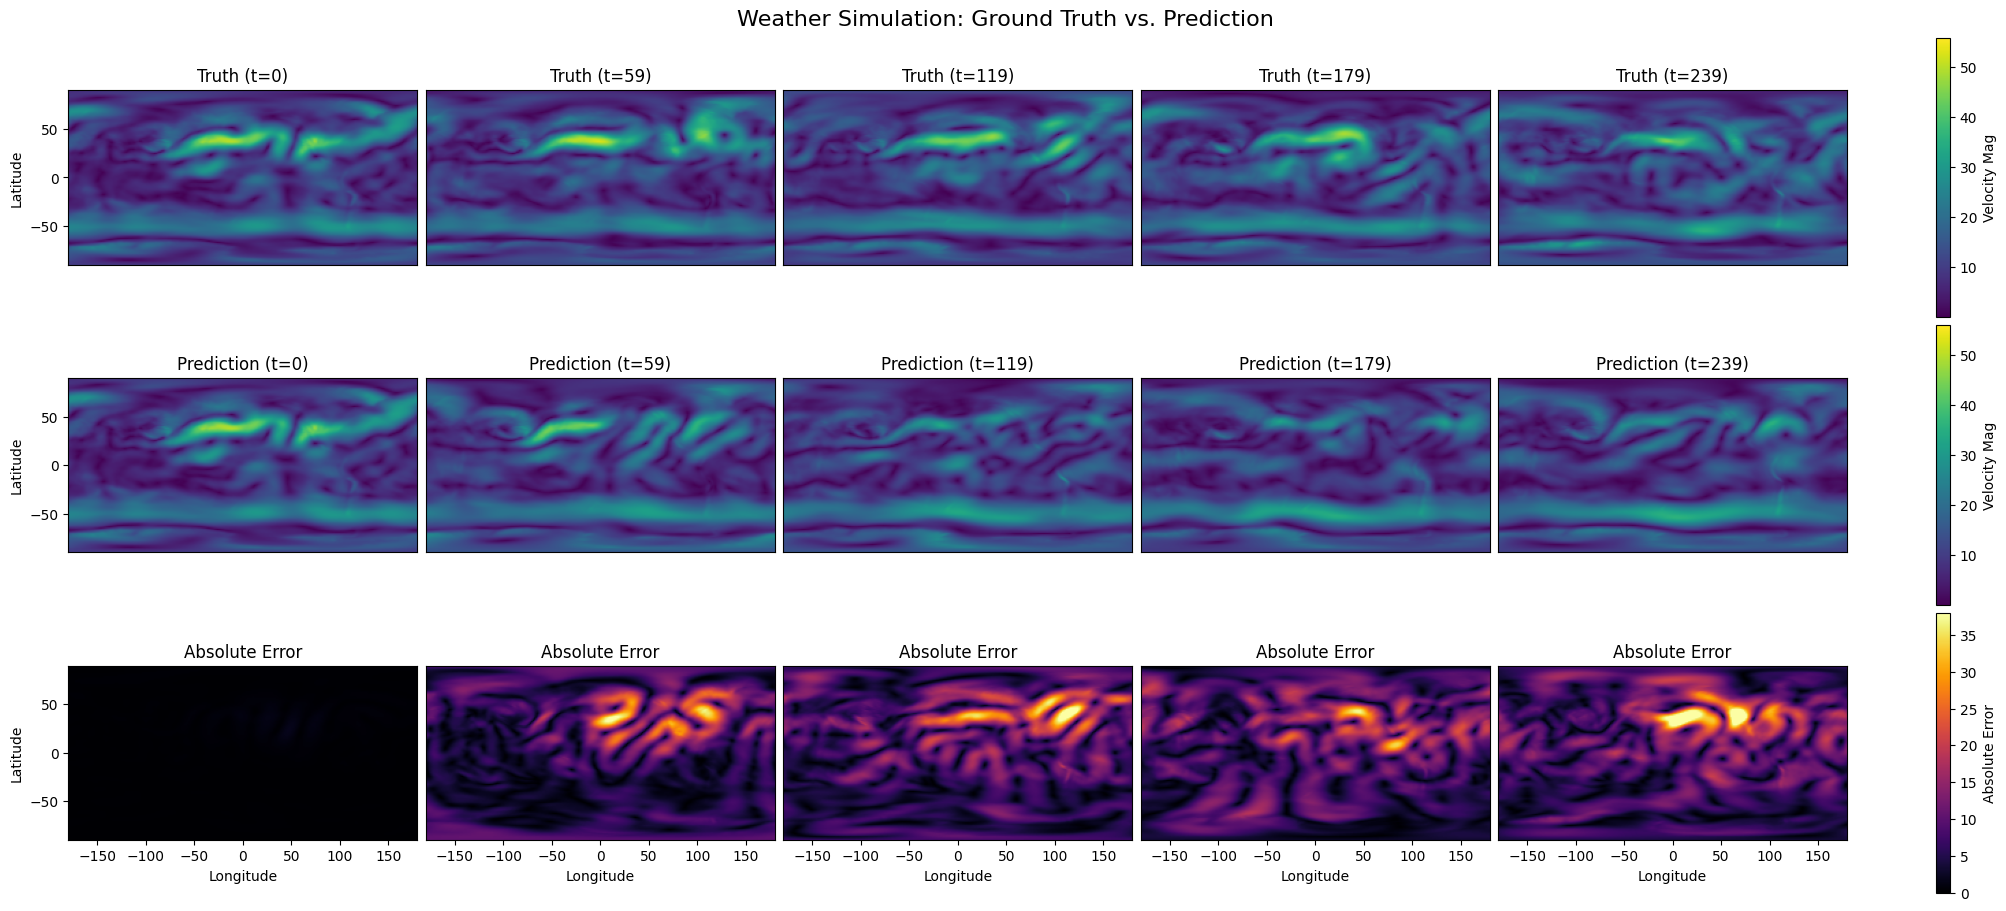

In [3]:
# DMD
t_hist, t_rollout = 12, 240
dmd = HankelDMDModel(latent_dim, delays=t_hist)
dmd = dmd.load("checkpoints/dmd.pkl")

# Predict with DMD
x = transformed_test[0:1, :t_hist]
print("Original shape:", x.shape)
pred_dmd = dmd.predict(x, t_rollout)
print("Predicted shape:", pred_dmd.shape)

# Inverse transform to original space
y_true = transformed_test[0:1, t_hist:t_hist+t_rollout]
y_true = pca.inverse_transform(y_true.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)
pred_dmd = pca.inverse_transform(pred_dmd.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)

# Plot
plot_weather(y_true[0], pred_dmd[0], num_steps=5)

## LatentFNO

Original shape: torch.Size([1, 1, 128])
Predicted shape: (1, 240, 128)


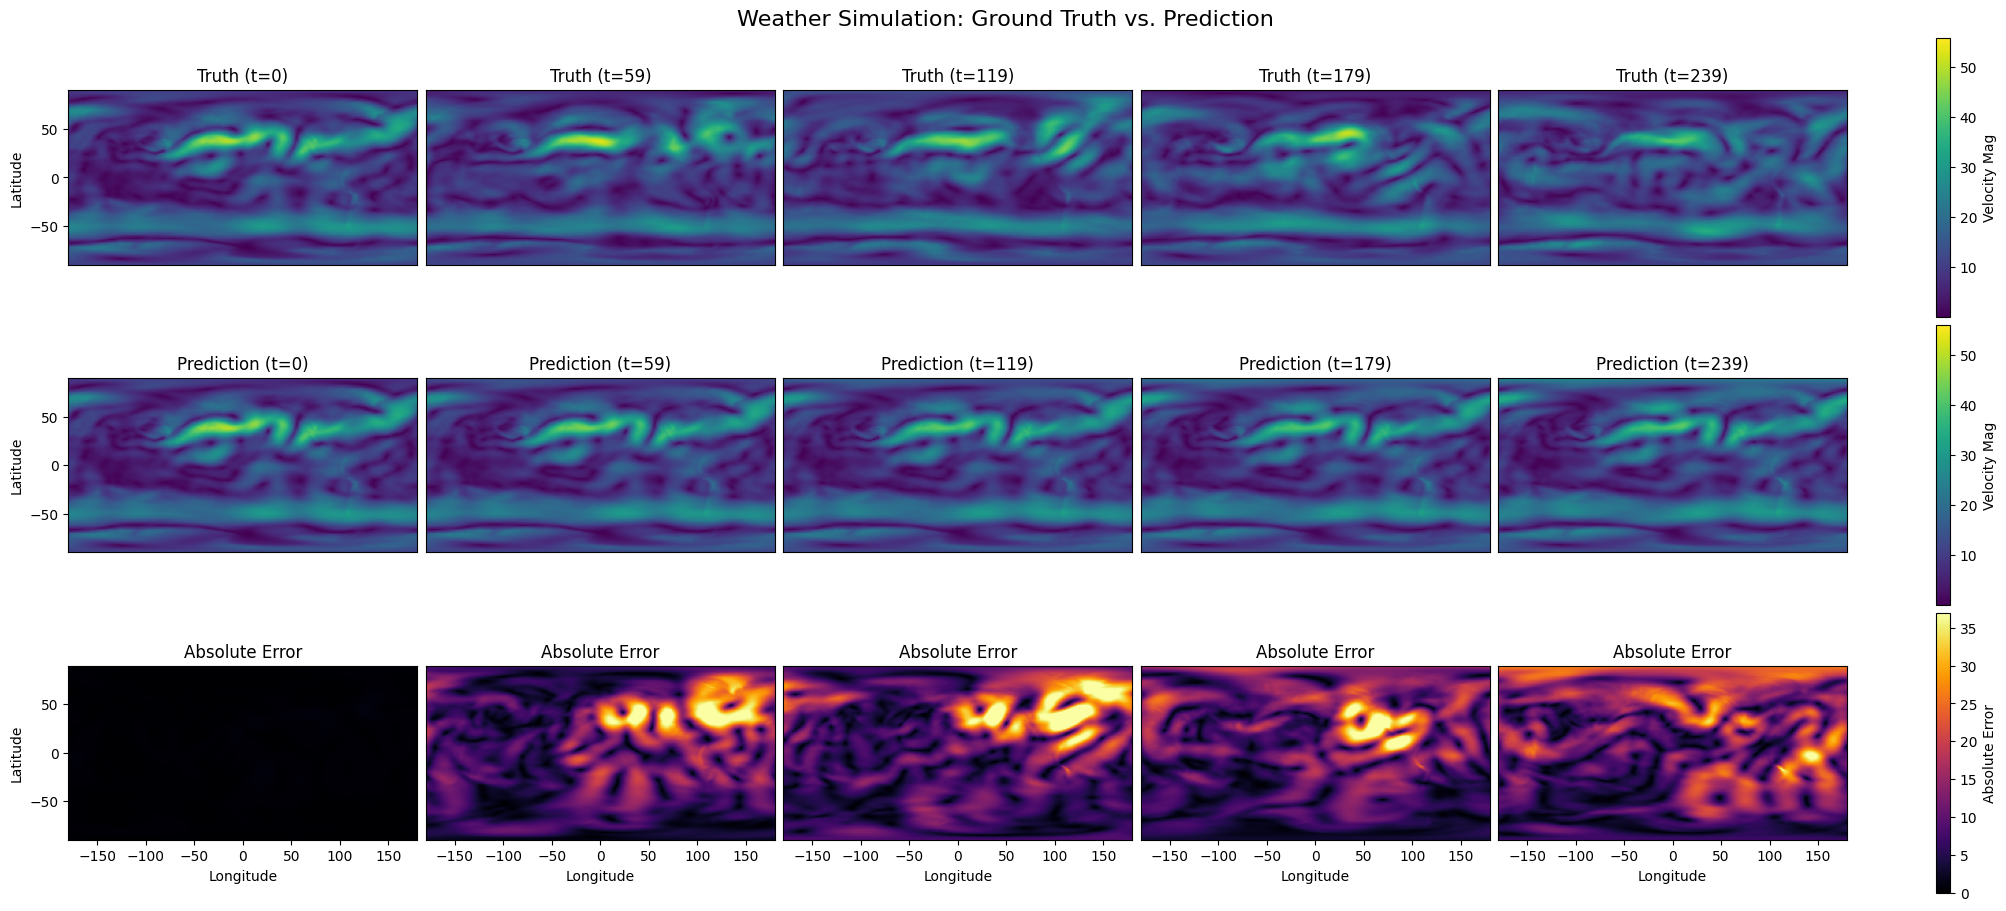

In [ ]:
# Transform test data to latent space
transformed_test_torch = torch.from_numpy(transformed_test).float()
t_hist, t_rollout = 1, 240
fno = LatentFNO(latent_dim=latent_dim, t_hist=t_hist, width=64, modes=32, n_layers=4).to(device)
fno.eval()
fno_state_dict = torch.load("checkpoints/fno.pth")

# Predict with FNO
x = transformed_test_torch[0:1, :t_hist].to(device)
print("Original shape:", x.shape)
with torch.no_grad():
    t_grid = torch.arange(t_hist, t_hist+t_rollout).float().unsqueeze(0).unsqueeze(-1).to(x.device)
    pred_fno = fno(x, t_grid, steps=t_rollout).detach().cpu().numpy()
print("Predicted shape:", pred_fno.shape)

# Inverse transform to original space
y_true = transformed_test_torch[0:1, t_hist:t_hist+t_rollout].cpu().numpy()
y_true = pca.inverse_transform(y_true.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)
pred_dmd = pca.inverse_transform(pred_fno.reshape(-1, latent_dim)).reshape(1, t_rollout, C, H, W)

# Plot
plot_weather(y_true[0], pred_dmd[0], num_steps=5)

## TFNO

In [ ]:
# Spectral downsampling
factor = 8
H_2, W_2 = H // factor, W // factor
print("Original shape:", torch_test.shape)
downsampled = spectral_downsample_2d(torch_test.view(-1, C, H, W), factor).view(B, T, C, H_2, W_2)
print("Downsampled shape:", downsampled.shape)

# TFNO
tfno = TFNO2D(
    factor=factor, in_channels=C, out_channels=C,
    in_time=t_hist, out_time=t_rollout,
    width=16,
    depth=4,
    modes_h=64,
    modes_w=32,
    factorization="tucker"
).to(device) 
tfno.eval()
tfno_state_dict = torch.load("checkpoints/tfno.pth")

# Predict with TFNO
t_hist, t_rollout = 1, 240
x = downsampled[0:1, :t_hist].to(device)
print("Original shape:", x.shape)
# Create (B, t_out, 1) time grid for TFNO
t_grid = torch.zeros((1, 1)).float().to(x.device)
print("Time grid shape:", t_grid.shape)
with torch.no_grad():
    pred_tfno = tfno(x, t_grid, steps=t_rollout).detach().cpu()
print("Predicted shape:", pred_tfno.shape)

# Spectral upsampling
pred_tfno_upsampled = spectral_upsample_2d(pred_tfno.view(-1, C, H_2, W_2), factor).view(1, t_rollout, C, H, W)
print("Upsampled shape:", pred_tfno_upsampled.shape)

# Plot
y_true = torch_test[0:1, t_hist:t_hist+t_rollout].cpu().numpy()
plot_weather(y_true[0], pred_tfno_upsampled[0], num_steps=5)

Original shape: torch.Size([4, 1008, 2, 128, 256])
Downsampled shape: torch.Size([4, 1008, 2, 32, 64])
Original shape: torch.Size([1, 1, 2, 32, 64])
Time grid shape: torch.Size([1, 1])
